# **XPM Unitary Operator Analysis**

This notebook loads trained parameters from a run directory and generates analysis plots for any unitary transformation (identity, permutation, rotation, or arbitrary).


In [132]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import json

# ML imports
import torch
import torch.nn.functional as F

# Import module
from nlse import *


In [133]:
plt.rcParams.update({'font.size': 16})


## **Setup: Load Run Directory**


In [134]:
# Specify the run directory to analyze
# You can change this to point to any run directory
run_dir = Path("res/identity-loss-hg-phase/")  # Change this to your run directory

print(f"Analyzing run directory: {run_dir}")


Analyzing run directory: res\identity-loss-hg-phase


## **Load Configuration and Parameters**


In [135]:
# Load configuration
config_path = run_dir / "config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Load losses
losses_path = run_dir / "losses.json"
with open(losses_path, "r") as f:
    losses = json.load(f)

# Load theta parameters
theta_path = run_dir / "parameters" / "theta.npy"
theta = torch.from_numpy(np.load(theta_path))

# Try to load transformation matrix (may not exist for older runs)
U_path = run_dir / "parameters" / "transformation_matrix.npy"
U_loaded = None
if U_path.exists():
    U_loaded = torch.from_numpy(np.load(U_path))
    print(f"Loaded transformation matrix with shape: {U_loaded.shape}")

print(f"Loaded theta with shape: {theta.shape}")
print(f"Configuration loaded from: {config_path}")
print(f"Losses loaded from: {losses_path}")


Loaded transformation matrix with shape: torch.Size([16, 16])
Loaded theta with shape: torch.Size([500])
Configuration loaded from: res\identity-loss-hg-phase\config.yaml
Losses loaded from: res\identity-loss-hg-phase\losses.json


## **Reconstruct Simulation Setup**


In [136]:
# Extract parameters from config
sim = config["simulation"]
med = config["medium"]
pulse = config["pulse"]
train = config["training"]
plot_config = config.get("plotting", {})

# Simulation parameters
Lz = float(sim["Lz"])
Nz = int(sim["Nz"])
Lt = float(sim["Lt"])
Nt = int(sim["Nt"])
N_modes = int(sim["N_modes"])

# Medium parameters
beta2_j = float(med["beta2_j"])
beta2_k = float(med["beta2_k"])
gamma_j = float(med["gamma_j"])
gamma_k = float(med["gamma_k"])

# Pulse parameters
tau = float(pulse["tau"])

# Training parameters
batch_size = int(train["batch_size"])
amplitude_downscale = float(train["amplitude_downscale"])

# Get transformation info (default to 'identity' for backward compatibility)
transformation_name = train.get("transformation", "identity")
transformation_seed = int(train.get("transformation_seed", 27))

# Calculate derived parameters
dz = Lz / Nz
dt = Lt / Nt

# Create time grid
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32, device=device)

# Define HG basis
hg_basis = get_hg_basis(N_modes, t, tau)

# Get batch of pulses (same as training)
B = batch_size
x = hg_basis[:B, :] * amplitude_downscale  # inputs
hg_basis_B = hg_basis[:B, :]  # truncated basis

print(f"Simulation setup reconstructed:")
print(f"  Lz={Lz}, Nz={Nz}, dz={dz}")
print(f"  Lt={Lt}, Nt={Nt}, dt={dt}")
print(f"  Batch size: {B}")
print(f"  HG modes: {N_modes}")
print(f"  Transformation: {transformation_name}")
print(f"  Transformation seed: {transformation_seed}")


Precomputed 500 HG basis functions on grid of 4096 points on device cpu
Simulation setup reconstructed:
  Lz=0.001, Nz=200, dz=5e-06
  Lt=16.0, Nt=4096, dt=0.00390625
  Batch size: 16
  HG modes: 500
  Transformation: identity
  Transformation seed: 27


Transformation matrix shape: torch.Size([16, 16])

Input x shape: torch.Size([16, 4096])
Target y shape: torch.Size([16, 4096])
Target y_hg shape: torch.Size([16, 16])


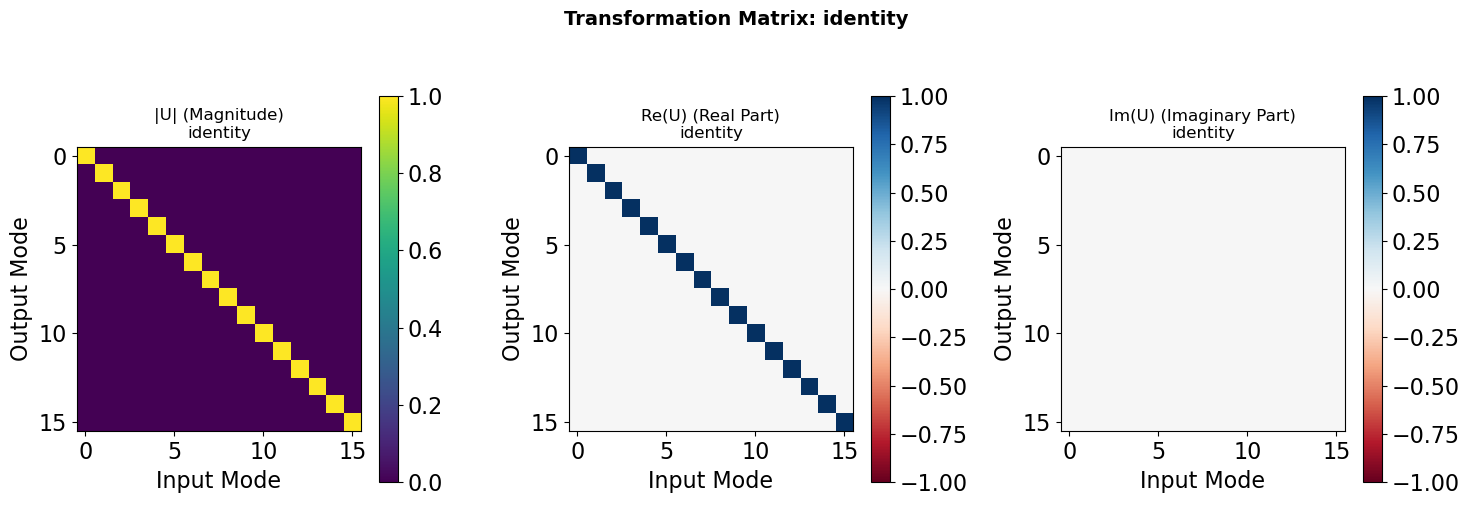

In [137]:
# Generate or use loaded transformation matrix
if U_loaded is not None:
    U = U_loaded
else:
    print(f"No generation loaded for '{run_dir}'")

print(f"Transformation matrix shape: {U.shape}")

# Generate target HG coefficients and time-domain signals
x_hg = torch.eye(B, dtype=torch.cfloat, device=device) * amplitude_downscale
y_hg = U @ x_hg  # Target HG coefficients

# Convert to time domain
y = torch.stack([hg_to_time(y_hg[i], hg_basis_B) for i in range(B)])

print(f"\nInput x shape: {x.shape}")
print(f"Target y shape: {y.shape}")
print(f"Target y_hg shape: {y_hg.shape}")

plot_transformation_matrix(U, transformation_name)


## **Forward Pass with Loaded Parameters**


In [138]:
""""---Define Loss Functions---"""
# only calculate mse loss, however
w_mse = float(train['w_mse'])

# MSE loss function (matches basic loss used in training)
def loss_function(A_j_evolution, A_k_evolution):
    mse_loss = F.mse_loss(torch.abs(A_j_evolution[:, :, -1])**2, torch.abs(y)**2)
    return w_mse * mse_loss

# HG coefficient loss function (matches the "hg_loss_function" used in training)
def hg_loss_function(A_j_evolution, A_k_evolution):
    final_j = A_j_evolution[:, :, -1]  # shape: (B, Nt)
    final_j_hg = torch.stack([time_to_hg(final_j[i], hg_basis_B, dt) for i in range(B)])  # shape: (B, B)
    mse_loss = F.mse_loss(torch.abs(final_j_hg)**2, torch.abs(y_hg)**2)
    return w_mse * mse_loss

In [139]:
# Define forward pass function (same as training)
def forward(theta, hg_basis):
    Ain_k = hg_to_time(theta, hg_basis)
    return split_step_fourier_xpm_batch(
        x, Ain_k, dz, Nz, 
        beta2_j, beta2_k, 
        gamma_j, gamma_k, 
        Lt
    )

# Run forward pass with loaded theta
print("Running forward pass with loaded theta...")
with torch.no_grad():
    A_j_evolution, A_k_evolution = forward(theta, hg_basis)

print(f"Forward pass completed!")
print(f"  A_j_evolution shape: {A_j_evolution.shape}")
print(f"  A_k_evolution shape: {A_k_evolution.shape}")

# Get trained strong pulse
Ain_k_trained = hg_to_time(theta, hg_basis)

# Calculate both losses
with torch.no_grad():
    # "normal" intensity loss
    mse_loss = loss_function(A_j_evolution, A_k_evolution)
    loss = mse_loss

    # hg coefficient loss
    hg_mse_loss = hg_loss_function(A_j_evolution, A_k_evolution)
    hg_loss = hg_mse_loss 

print(f"\nFinal forward-pass loss (intensity): MSE={mse_loss.item():.6f}")
print(f"Final forward-pass HG loss: MSE={hg_mse_loss.item():.6f}")


Running forward pass with loaded theta...


Forward pass completed!
  A_j_evolution shape: torch.Size([16, 4096, 201])
  A_k_evolution shape: torch.Size([16, 4096, 201])

Final forward-pass loss (intensity): MSE=0.079279
Final forward-pass HG loss: MSE=0.043460


## **Analysis**

### 1. Training Loss


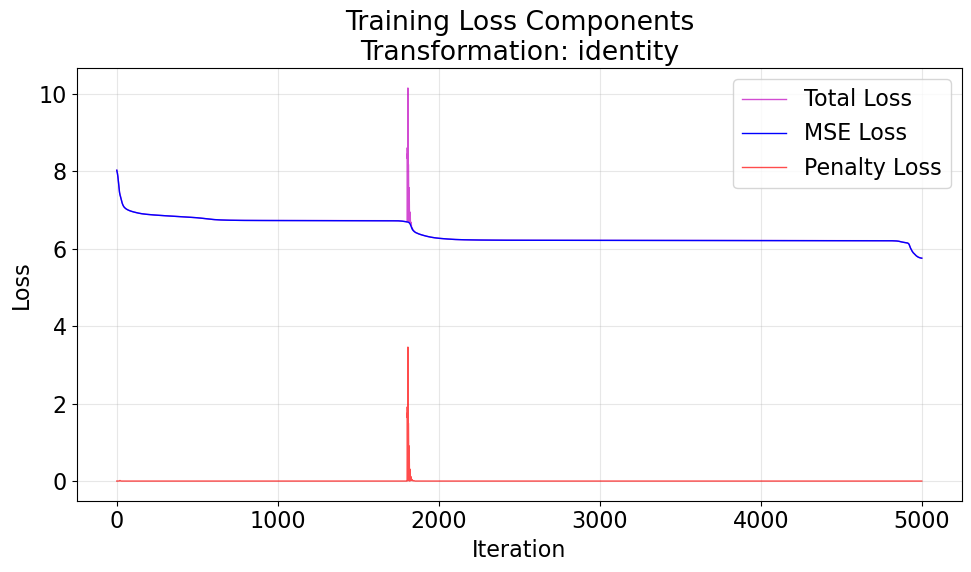

Final Loss: 5.757098
Final MSE Loss: 5.757033
Final Penalty Loss: 6.415094e-05
Best Loss: 5.757098 (iteration 4999)


In [140]:
# Plot the training loss
plt.figure(figsize=(10, 6))
plt.plot(losses["losses"], color="m", label="Total Loss", linewidth=1, alpha=0.7)
plt.plot(losses["losses_mse"], color="b", label="MSE Loss", linewidth=1)
plt.plot(losses["losses_pen"], color="r", label="Penalty Loss", linewidth=1, alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"Training Loss Components\nTransformation: {transformation_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Loss: {losses['final_loss']:.6f}")
print(f"Final MSE Loss: {losses['final_loss_mse']:.6f}")
print(f"Final Penalty Loss: {losses['final_loss_pen']:.6e}")
if 'best_loss' in losses:
    print(f"Best Loss: {losses['best_loss']:.6f} (iteration {losses.get('best_iteration', 'N/A')})")


In [141]:
# Plotting setup
plot_percent = plot_config.get("plot_percent", 0.3)
modes_to_plot = plot_config.get("modes_to_plot", [0, 4, 15])

# Calculate the indices for the central portion
total_points = len(t)
center_points = int(total_points * plot_percent)
start_idx = (total_points - center_points) // 2
end_idx = start_idx + center_points
t_center = t[start_idx:end_idx].cpu().numpy()

print(f"Plotting parameters:")
print(f"  Plot percent: {plot_percent}")
print(f"  Modes to plot: {modes_to_plot}")


Plotting parameters:
  Plot percent: 0.3
  Modes to plot: [0, 4, 15]


### 3. Analyzing Specific Mode


In [142]:
# ===== PARAMETER: Set the mode number to analyze =====
mode_nr = 3  # Change this to analyze different modes (0 to B-1)
# ======================================================


In [143]:
# # Plot intensity evolution for wave j
# plot_intensity_evolution(A_j_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave j")

# # Plot intensity evolution for wave k
# plot_intensity_evolution(A_k_evolution[mode_nr, :, :], t, Lz, Nz, wave_name="Wave k")

# # Plot co-wave evolution
# plot_cowave_evolution(
#     A_j_evolution[mode_nr, :, :].detach().clone(),
#     A_k_evolution[mode_nr, :, :].detach().clone(),
#     t,
#     Lz,
#     Nz
# )


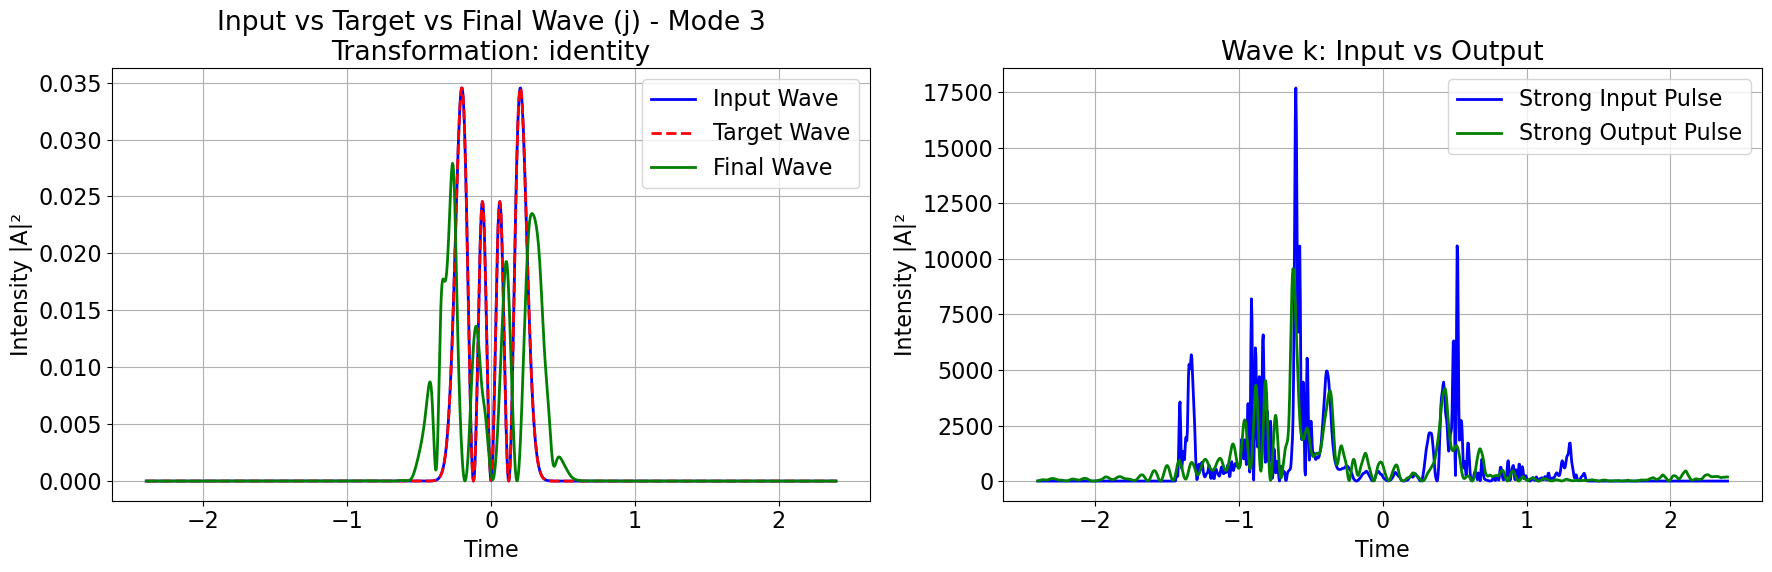

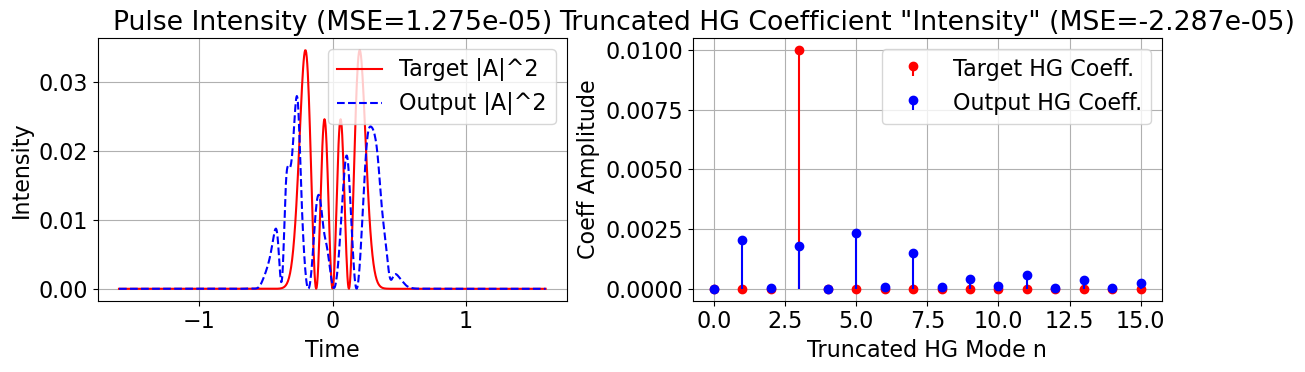

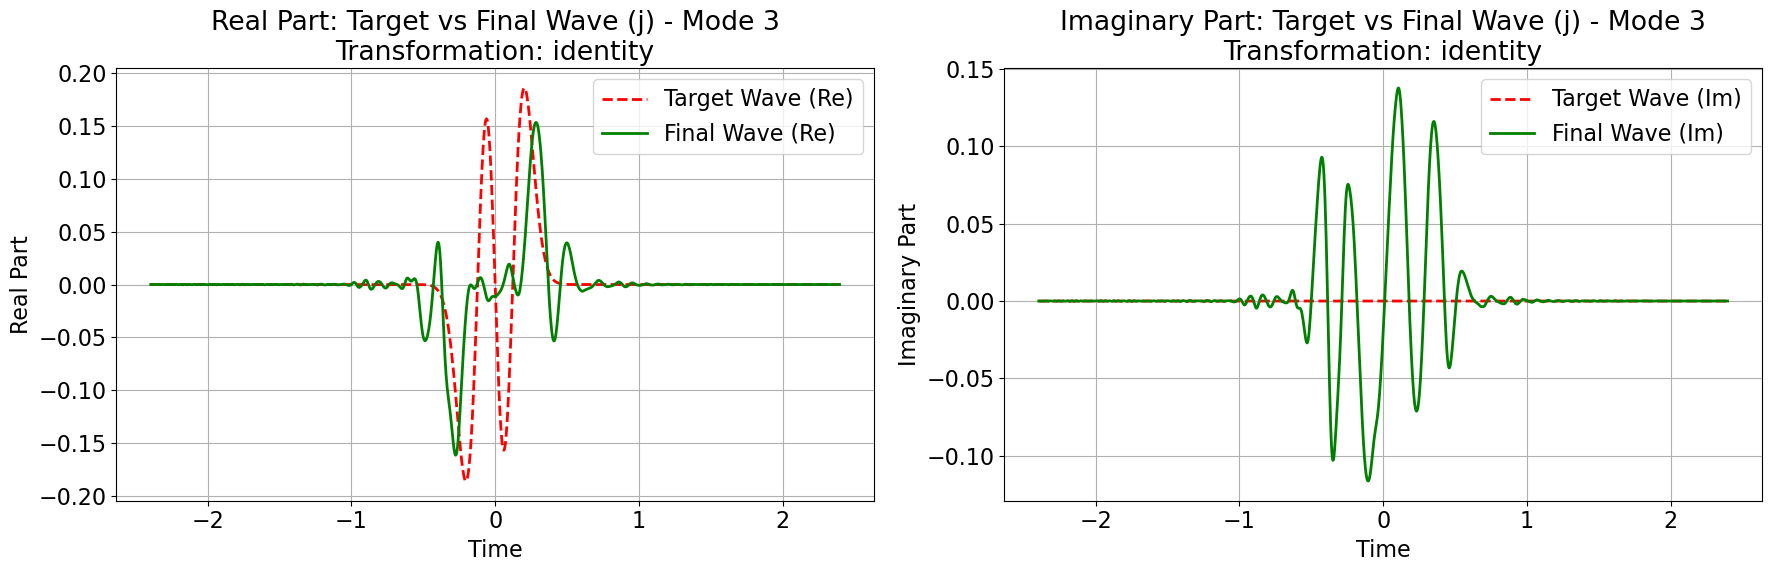

In [144]:
"""------Target vs Final Wave------"""
# Plot target vs final wave comparison
plot_percent_comparison = 0.3
center_points_comp = int(total_points * plot_percent_comparison)
start_idx_comp = (total_points - center_points_comp) // 2
end_idx_comp = start_idx_comp + center_points_comp
t_center_comp = t[start_idx_comp:end_idx_comp].cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# First subplot: Input vs Target vs Final wave (j)
ax1.plot(t_center_comp, np.abs(x[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Input Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(y[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "r--", label="Target Wave", linewidth=2)
ax1.plot(t_center_comp, np.abs(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Final Wave", linewidth=2)
ax1.set_xlabel("Time")
ax1.set_ylabel("Intensity |A|²")
ax1.set_title(f"Input vs Target vs Final Wave (j) - Mode {mode_nr}\nTransformation: {transformation_name}")
ax1.legend()
ax1.grid()

# Second subplot: Wave k first and last
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, 0].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "b-", label="Strong Input Pulse", linewidth=2)
ax2.plot(t_center_comp, np.abs(A_k_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp]**2, 
        "g-", label="Strong Output Pulse", linewidth=2)
ax2.set_xlabel("Time")
ax2.set_ylabel("Intensity |A|²")
ax2.set_title("Wave k: Input vs Output")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

analyze(A_j_evolution[mode_nr,:, -1], y[mode_nr], hg_basis, dt, B, Lt, Nt)

# Plot the real and imaginary parts of the target and final states
fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(18, 6))

# Real part subplot
ax_re.plot(
    t_center_comp, 
    np.real(y[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp], 
    "r--", label="Target Wave (Re)", linewidth=2)
ax_re.plot(
    t_center_comp, 
    np.real(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp], 
    "g-", label="Final Wave (Re)", linewidth=2)
ax_re.set_xlabel("Time")
ax_re.set_ylabel("Real Part")
ax_re.set_title(f"Real Part: Target vs Final Wave (j) - Mode {mode_nr}\nTransformation: {transformation_name}")
ax_re.legend()
ax_re.grid()

# Imaginary part subplot
ax_im.plot(
    t_center_comp, 
    np.imag(y[mode_nr].detach().cpu().numpy())[start_idx_comp:end_idx_comp],
    "r--", label="Target Wave (Im)", linewidth=2)
ax_im.plot(
    t_center_comp, 
    np.imag(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx_comp:end_idx_comp],
    "g-", label="Final Wave (Im)", linewidth=2)
ax_im.set_xlabel("Time")
ax_im.set_ylabel("Imaginary Part")
ax_im.set_title(f"Imaginary Part: Target vs Final Wave (j) - Mode {mode_nr}\nTransformation: {transformation_name}")
ax_im.legend()
ax_im.grid()

plt.tight_layout()
plt.show()




### 4. Full Mode Comparison

Grid plot showing target vs output for all modes.


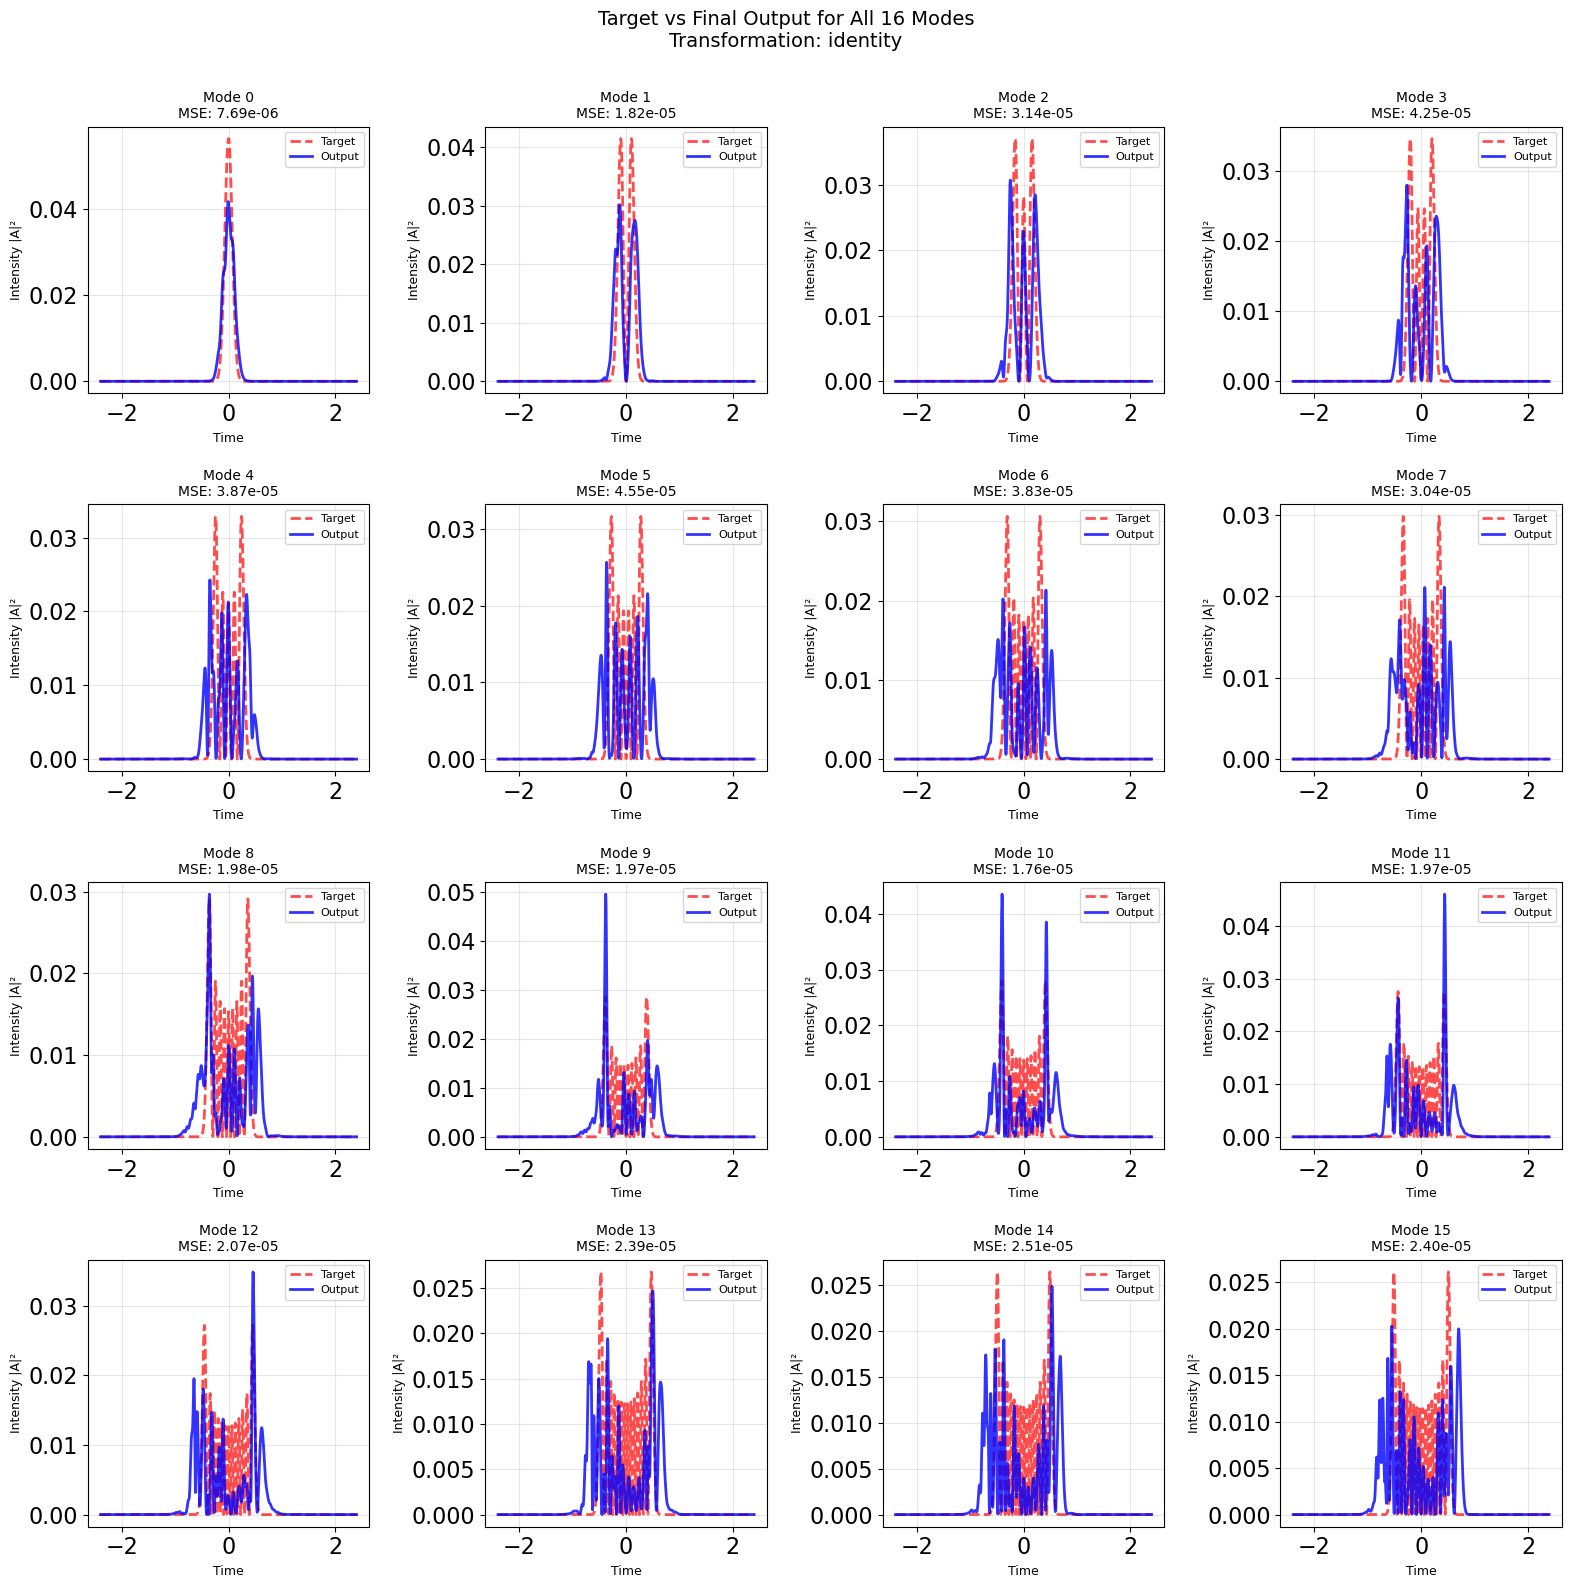

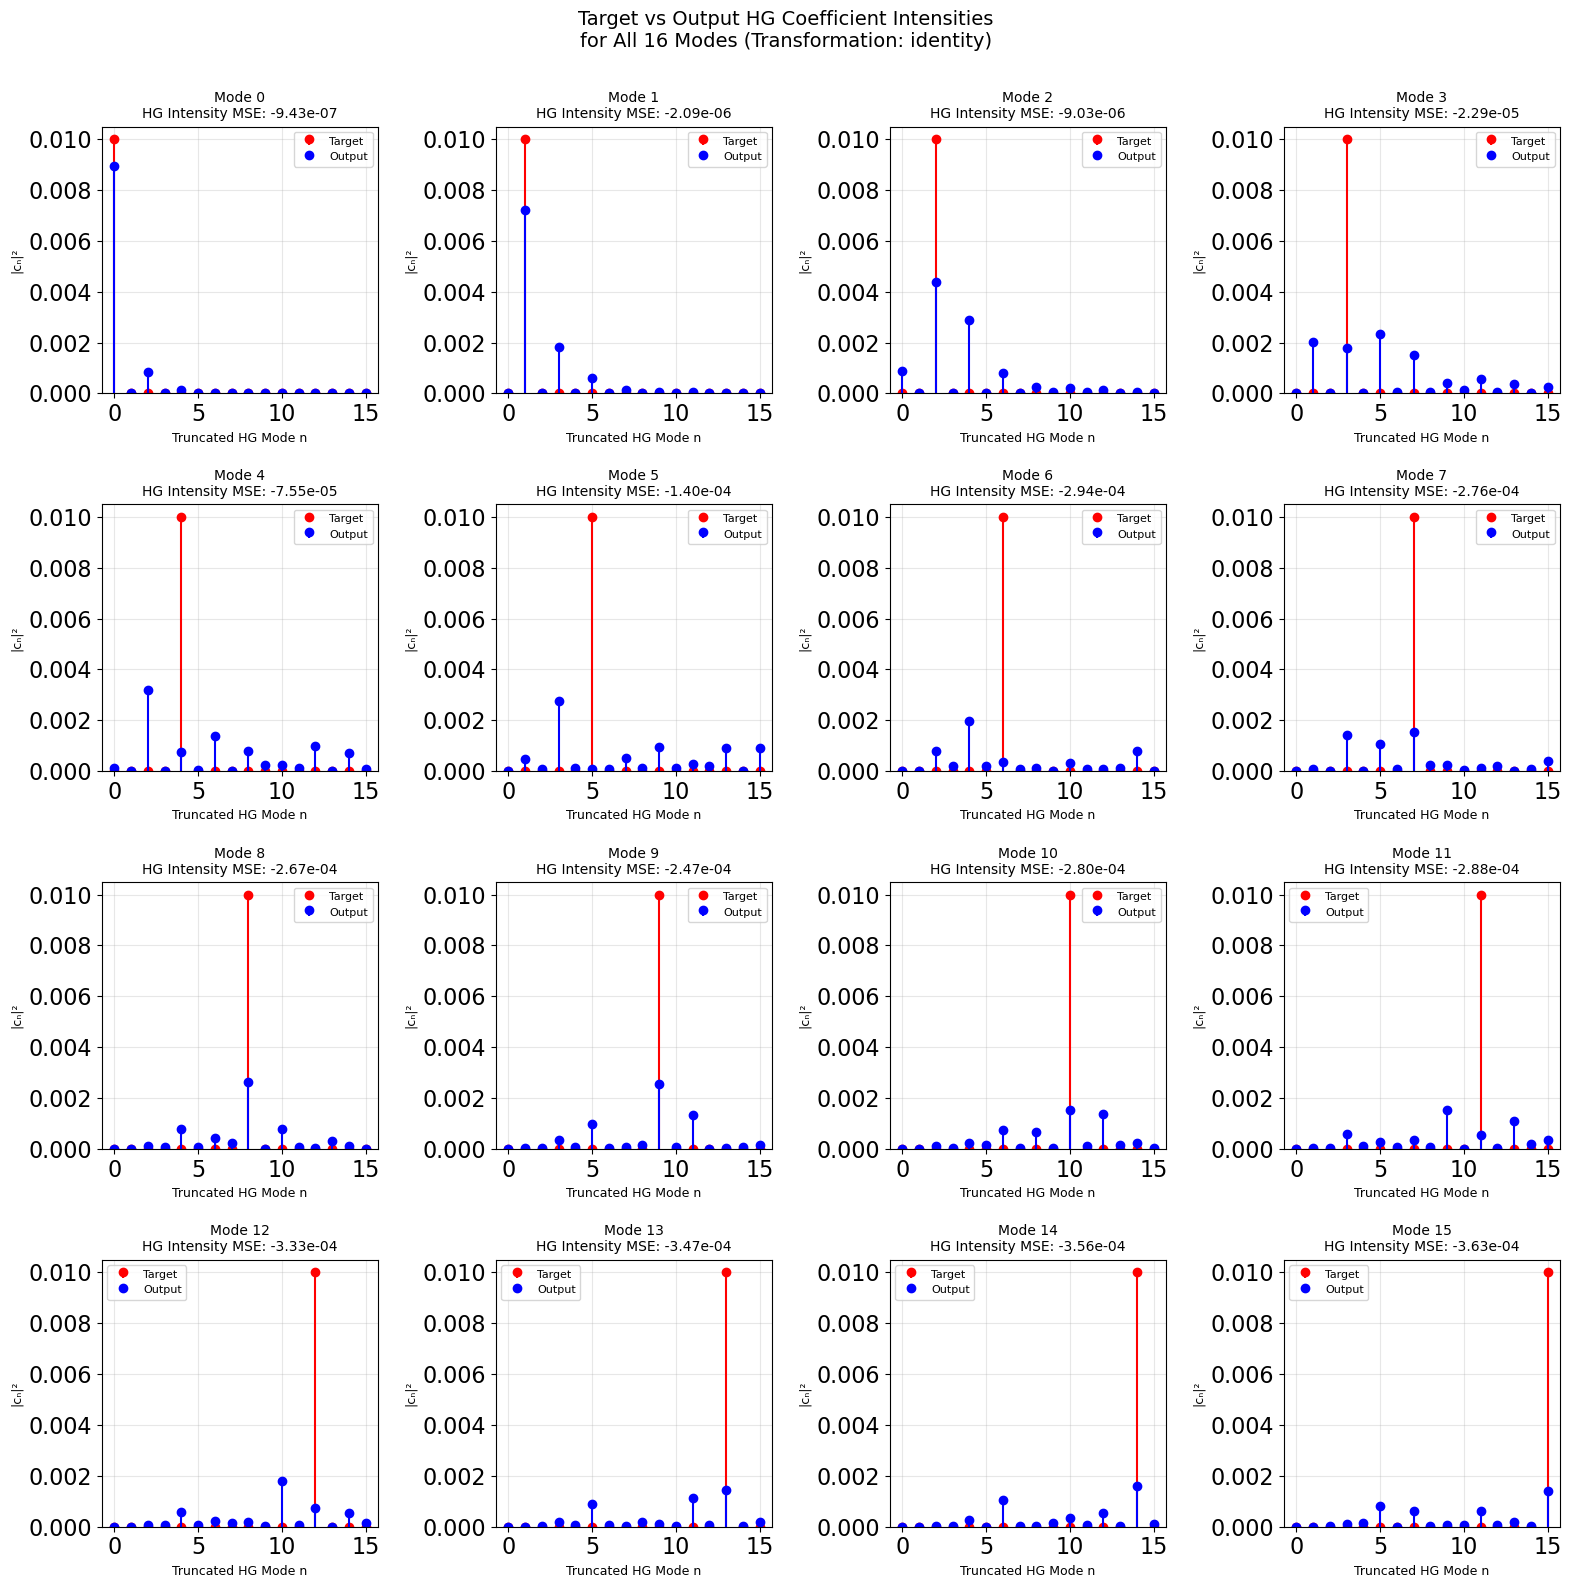

In [145]:
# Generate mode comparison plot
plot_mode_comparison(y, t, A_j_evolution, plot_percent=0.3, transformation_name=transformation_name)
plot_mode_comparison_hg(y, A_j_evolution, hg_basis, dt, transformation_name=transformation_name)

### 5. Full Mode HG Coefficient Plot

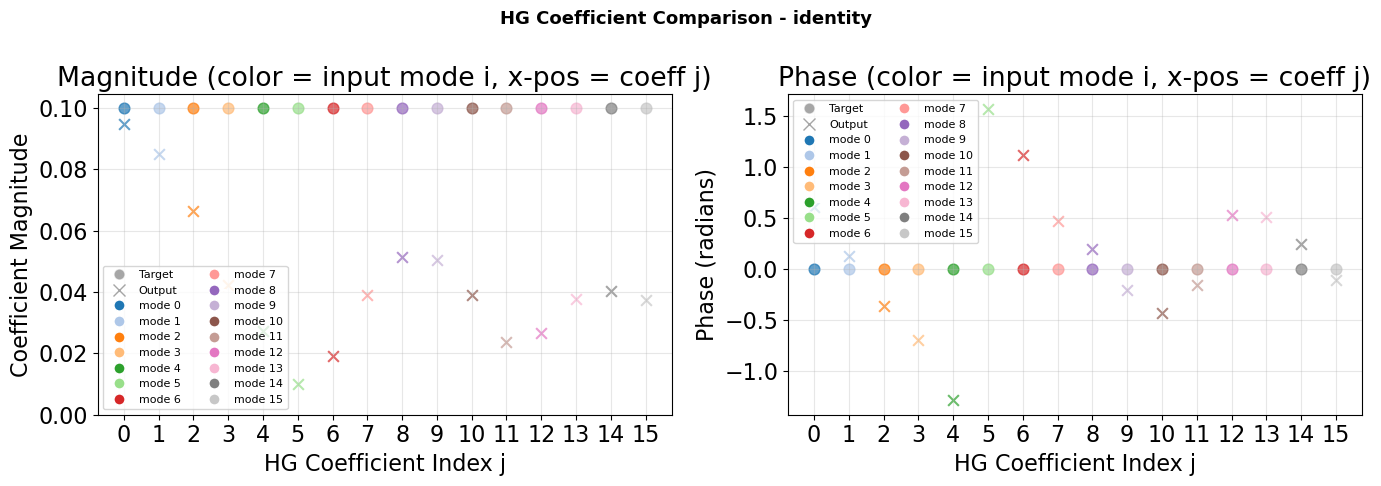


HG Coefficient Error Metrics:
  Mean coefficient error: 1.59e-02
  Max coefficient error: 1.00e-01


In [146]:
plot_mode_hg_coeffs(y, A_j_evolution, hg_basis, dt, num_modes = 16, threshold_percent = 0.01, transformation_name=transformation_name)

Global Phase Shift Adjusted

Mean Phase Output: 0.13296807
Mean Phase Target: 0.0
Global Phase Shift: 0.13296807


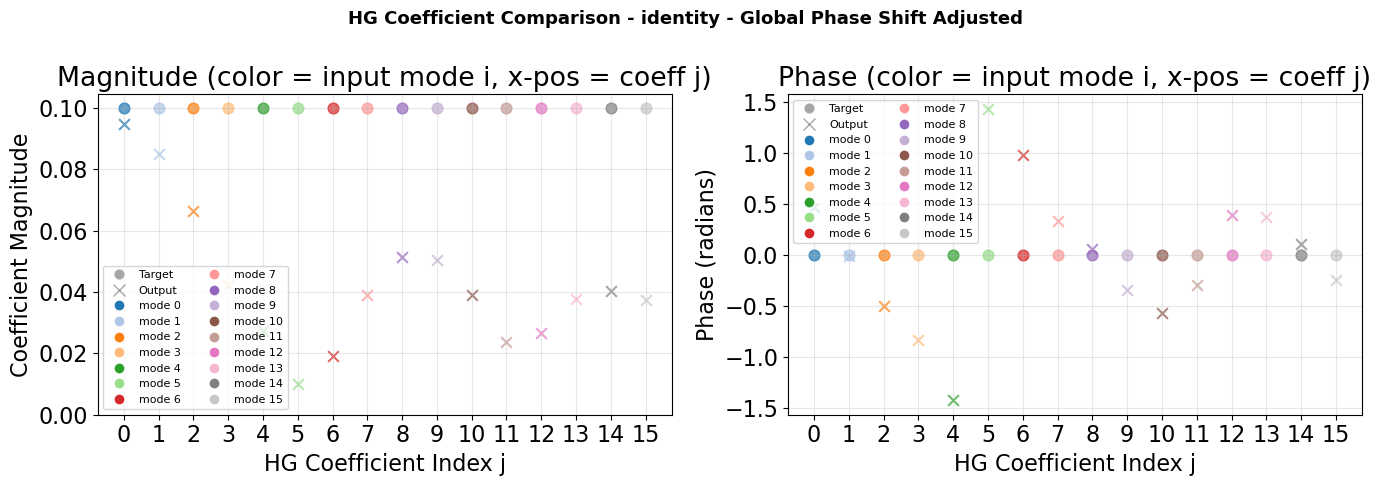

In [147]:
num_modes = B
threshold_percent = 0.5

coeff_target = []
coeff_output = []
for mode_idx in range(B):
    c_target = time_to_trunc_hg(y[mode_idx].detach(), hg_basis, dt, num_modes).cpu().numpy()
    c_output = time_to_trunc_hg(A_j_evolution[mode_idx, :, -1].detach(), hg_basis, dt, num_modes).cpu().numpy()
    coeff_target.append(c_target)
    coeff_output.append(c_output)
coeff_target = np.stack(coeff_target)  # (B, num_modes) — row i = output coefficients for input mode i
coeff_output = np.stack(coeff_output)  # (B, num_modes)

coeff_indices = np.arange(num_modes)
colors = plt.cm.tab20(np.arange(B))

# get phases
target_phase = np.angle(coeff_target)
output_phase = np.angle(coeff_output)


'''------Find Global Phase Shift------'''
sig_output_phases = []
sig_target_phases = []
for i in range(B):
    row_max = np.max(np.abs(coeff_target[i, :]))
    if row_max == 0:
        continue
    significant = np.abs(coeff_target[i, :]) > 0.5 * row_max # get filter for significant components
    js = coeff_indices[significant] # get significant indices
    
    sig_output_phases.append(np.mean(output_phase[i,js])) # if more than one significant target/output phase, take their mean
    sig_target_phases.append(np.mean(target_phase[i,js]))
global_phase_shift = np.mean(sig_output_phases) - np.mean(sig_target_phases)

print("Mean Phase Output:", np.mean(sig_output_phases))
print("Mean Phase Target:", np.mean(sig_target_phases))
print("Global Phase Shift:", global_phase_shift)


'''------Make Phase Adjusted Plot------'''
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Magnitude plot ---
ax1 = axes[0]
for i in range(B):
    row_max = np.max(np.abs(coeff_target[i, :]))
    if row_max == 0:
        continue
    significant = np.abs(coeff_target[i, :]) > threshold_percent * row_max #* note: filtering is based on target coefficients
    js = coeff_indices[significant]

    ax1.scatter(js, np.abs(coeff_target[i, js]), s=60, c=[colors[i]], marker='o', alpha=0.7)
    ax1.scatter(js, np.abs(coeff_output[i, js]), s=60, c=[colors[i]], marker='x', alpha=0.7)

ax1.set_xlabel('HG Coefficient Index j')
ax1.set_ylabel('Coefficient Magnitude')
ax1.set_title('Magnitude (color = input mode i, x-pos = coeff j)')
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(coeff_indices)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Target', markersize=8, alpha=0.7),
    plt.Line2D([0], [0], marker='x', color='w', markerfacecolor='gray', markeredgecolor='gray', label='Output', markersize=8, alpha=0.7),
] + [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], label=f'mode {i}', markersize=8)
    for i in range(B)
]
ax1.legend(handles=legend_elements, fontsize=8, ncol=2)

# --- Phase plot ---
ax2 = axes[1]

for i in range(B):
    row_max = np.max(np.abs(coeff_target[i, :]))
    if row_max == 0:
        continue
    significant = np.abs(coeff_target[i, :]) > 0.5 * row_max # get filter for significant components
    js = coeff_indices[significant] # get significant indices

    ax2.scatter(js, target_phase[i, js], s=60, c=[colors[i]], marker='o', alpha=0.7)
    ax2.scatter(js, output_phase[i, js] - global_phase_shift, s=60, c=[colors[i]], marker='x', alpha=0.7)

ax2.set_xlabel('HG Coefficient Index j')
ax2.set_ylabel('Phase (radians)')
ax2.set_title('Phase (color = input mode i, x-pos = coeff j)')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(coeff_indices)

legend_elements_phase = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', label='Target', markersize=8, alpha=0.7),
    plt.Line2D([0], [0], marker='x', color='w', markerfacecolor='gray', markeredgecolor='gray', label='Output', markersize=8, alpha=0.7),
] + [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], label=f'mode {i}', markersize=8)
    for i in range(B)
]
ax2.legend(handles=legend_elements_phase, fontsize=8, ncol=2)

plt.suptitle(f'HG Coefficient Comparison - {transformation_name} - Global Phase Shift Adjusted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Random Mode Combination Test

Test the learned operator with a random combination of modes.


In [148]:
# ===== PARAMETER: Set the number of modes to use =====
num_modes_to_use = 7  # Change this to use fewer modes (max = B)
random_seed = 42  # For reproducibility
# ======================================================

# Generate random coefficients
np.random.seed(random_seed)
random_coeffs = np.zeros(B, dtype=np.complex128)
random_coeffs[:num_modes_to_use] = np.random.randn(num_modes_to_use) + 1j * np.random.randn(num_modes_to_use) * 0.1
random_coeffs = random_coeffs / np.linalg.norm(random_coeffs)  # Normalize

random_coeffs_torch = torch.tensor(random_coeffs, dtype=torch.cfloat, device=device)

# Create random combination pulse in time domain
random_pulse = torch.sum(random_coeffs_torch.unsqueeze(1) * x, dim=0)

# Compute expected output using target transformation
expected_output_hg = U @ (random_coeffs_torch * amplitude_downscale)
expected_output = hg_to_time(expected_output_hg, hg_basis_B)

print(f"Number of modes used: {num_modes_to_use}/{B}")
print(f"Random coefficients L2 norm: {torch.norm(random_coeffs_torch).item():.6f}")
print(f"Random pulse shape: {random_pulse.shape}")


Number of modes used: 7/16
Random coefficients L2 norm: 1.000000
Random pulse shape: torch.Size([4096])


In [149]:
# Run forward pass with the random pulse
random_pulse_batch = random_pulse.unsqueeze(0)

print("Running forward pass with random combination pulse...")
with torch.no_grad():
    A_j_random_evolution, A_k_random_evolution = split_step_fourier_xpm_batch(
        random_pulse_batch, Ain_k_trained, dz, Nz,
        beta2_j, beta2_k, gamma_j, gamma_k, Lt
    )

actual_output = A_j_random_evolution[0, :, -1]
print(f"Forward pass completed!")
print(f"  Actual output shape: {actual_output.shape}")


Running forward pass with random combination pulse...
Forward pass completed!
  Actual output shape: torch.Size([4096])


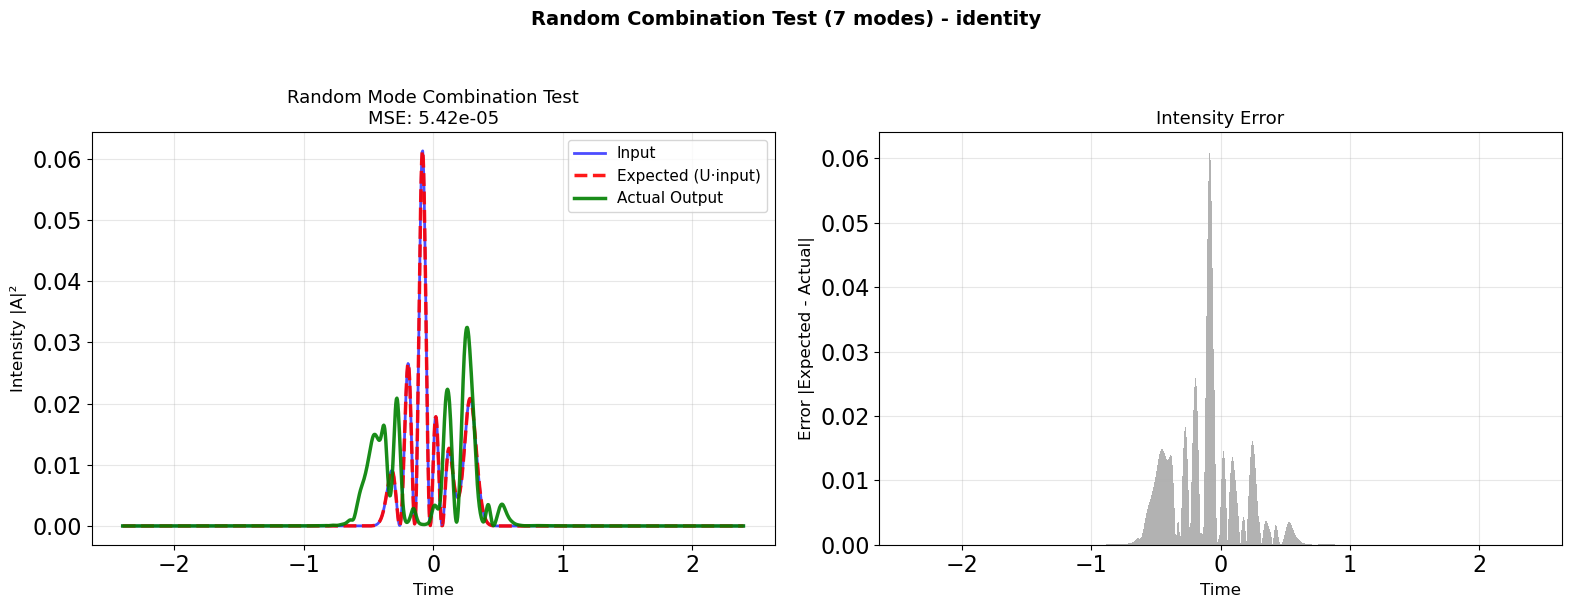


Random Combination Results:
  MSE: 5.42e-05
  Max Error: 6.10e-02
  Mean Error: 2.44e-03


In [150]:
# Prepare data for plotting
plot_percent_random = 0.3
center_points_random = int(total_points * plot_percent_random)
start_idx_random = (total_points - center_points_random) // 2
end_idx_random = start_idx_random + center_points_random
t_plot_random = t[start_idx_random:end_idx_random].cpu().numpy()

# Extract intensities
input_intensity = np.abs(random_pulse.detach().cpu().numpy())[start_idx_random:end_idx_random]**2
expected_intensity = np.abs(expected_output.detach().cpu().numpy())[start_idx_random:end_idx_random]**2
actual_intensity = np.abs(actual_output.detach().cpu().numpy())[start_idx_random:end_idx_random]**2
error = np.abs(expected_intensity - actual_intensity)

# Calculate MSE
mse_random = np.mean((expected_intensity - actual_intensity)**2)

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Input, Expected, Actual
ax1 = axes[0]
ax1.plot(t_plot_random, input_intensity, 'b-', linewidth=2, label='Input', alpha=0.7)
ax1.plot(t_plot_random, expected_intensity, 'r--', linewidth=2.5, label='Expected (U·input)', alpha=0.9)
ax1.plot(t_plot_random, actual_intensity, 'g-', linewidth=2.5, label='Actual Output', alpha=0.9)
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Intensity |A|²', fontsize=12)
ax1.set_title(f'Random Mode Combination Test\nMSE: {mse_random:.2e}', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Right plot: Error
ax2 = axes[1]
ax2.bar(t_plot_random, error, width=(t_plot_random[1]-t_plot_random[0]), color='gray', alpha=0.6)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('Error |Expected - Actual|', fontsize=12)
ax2.set_title('Intensity Error', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Random Combination Test ({num_modes_to_use} modes) - {transformation_name}', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRandom Combination Results:")
print(f"  MSE: {mse_random:.2e}")
print(f"  Max Error: {error.max():.2e}")
print(f"  Mean Error: {error.mean():.2e}")


### 7. HG Coefficients Comparison for Random Combination


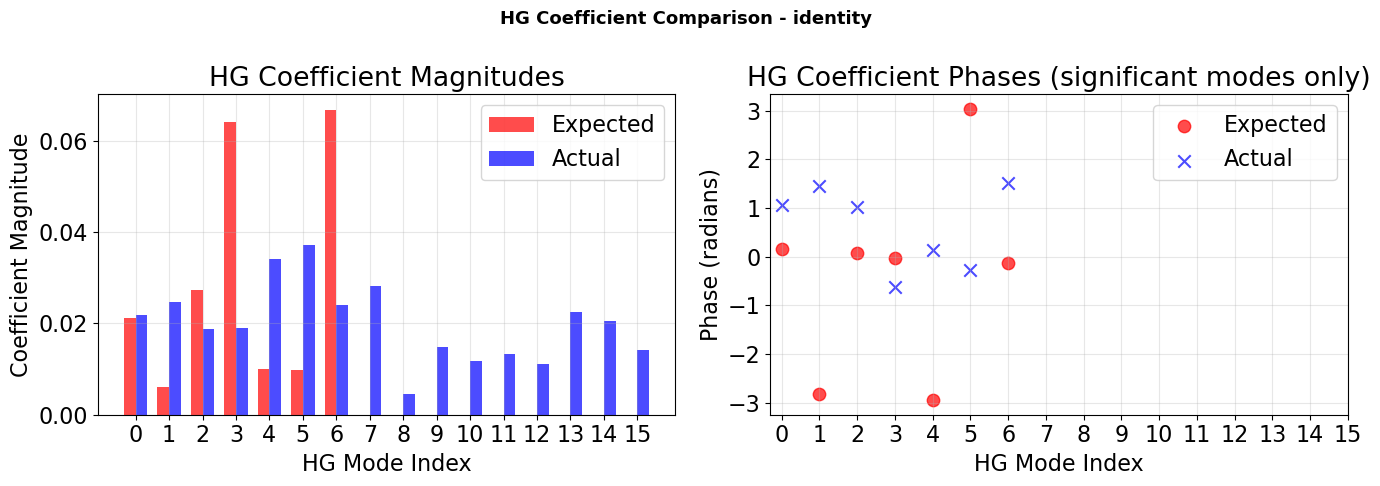


HG Coefficient Error Metrics:
  Mean coefficient error: 2.65e-02
  Max coefficient error: 7.25e-02


In [151]:
def plot_hg_coefficient_comparison(expected_output, actual_output, hg_basis_B, B, dt, device, transformation_name):
    """
    Compute and plot HG coefficients for expected and actual outputs.

    Parameters:
        expected_output (torch.Tensor): The expected output vector.
        actual_output (torch.Tensor): The actual output vector.
        hg_basis_B (torch.Tensor): The set of HG basis vectors, of shape (B, N).
        B (int): Number of HG modes/basis.
        dt (float): Time step.
        device (torch.device): Torch device (cpu or cuda).
        transformation_name (str): Name of the transformation (for titles).
    """
    # Compute HG coefficients for expected and actual outputs
    expected_hg_coeffs = torch.zeros(B, dtype=torch.cfloat, device=device)
    actual_hg_coeffs = torch.zeros(B, dtype=torch.cfloat, device=device)

    for i in range(B):
        expected_hg_coeffs[i] = torch.sum(expected_output * torch.conj(hg_basis_B[i])) * dt
        actual_hg_coeffs[i] = torch.sum(actual_output * torch.conj(hg_basis_B[i])) * dt

    mode_indices = np.arange(B)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Magnitude comparison
    ax1 = axes[0]
    width = 0.35
    ax1.bar(mode_indices - width/2, torch.abs(expected_hg_coeffs).cpu().numpy(), width, 
            label='Expected', color='red', alpha=0.7)
    ax1.bar(mode_indices + width/2, torch.abs(actual_hg_coeffs).cpu().numpy(), width, 
            label='Actual', color='blue', alpha=0.7)
    ax1.set_xlabel('HG Mode Index')
    ax1.set_ylabel('Coefficient Magnitude')
    ax1.set_title('HG Coefficient Magnitudes')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(mode_indices)

    # Phase comparison (for non-zero coefficients)
    ax2 = axes[1]
    expected_phase = torch.angle(expected_hg_coeffs).cpu().numpy()
    actual_phase = torch.angle(actual_hg_coeffs).cpu().numpy()
    # Only show phase for significant coefficients
    threshold = 0.01 * torch.max(torch.abs(expected_hg_coeffs)).item()
    significant = torch.abs(expected_hg_coeffs).cpu().numpy() > threshold

    ax2.scatter(mode_indices[significant], expected_phase[significant], s=80, c='red', 
                marker='o', label='Expected', alpha=0.7)
    ax2.scatter(mode_indices[significant], actual_phase[significant], s=80, c='blue', 
                marker='x', label='Actual', alpha=0.7)
    ax2.set_xlabel('HG Mode Index')
    ax2.set_ylabel('Phase (radians)')
    ax2.set_title('HG Coefficient Phases (significant modes only)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(mode_indices)

    plt.suptitle(f'HG Coefficient Comparison - {transformation_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Coefficient error metrics
    coeff_error = torch.abs(expected_hg_coeffs - actual_hg_coeffs)
    print(f"\nHG Coefficient Error Metrics:")
    print(f"  Mean coefficient error: {coeff_error.mean().item():.2e}")
    print(f"  Max coefficient error: {coeff_error.max().item():.2e}")

# Call the function with the relevant arguments
plot_hg_coefficient_comparison(
    expected_output=expected_output,
    actual_output=actual_output,
    hg_basis_B=hg_basis_B,
    B=B,
    dt=dt,
    device=device,
    transformation_name=transformation_name
)




### 8. Linearity Check

Test if the learned operator is linear: $T(a \cdot x_1 + b \cdot x_2) \approx a \cdot T(x_1) + b \cdot T(x_2)$


In [152]:
# ===== USER PARAMETERS =====
mode_1_idx = 2
mode_2_idx = 8
coeff_a = 0.5
coeff_b = 0.5
# ===========================

print(f"Linearity Test Configuration:")
print(f"  Mode 1 index: {mode_1_idx}")
print(f"  Mode 2 index: {mode_2_idx}")
print(f"  Coefficient a: {coeff_a}")
print(f"  Coefficient b: {coeff_b}")


Linearity Test Configuration:
  Mode 1 index: 2
  Mode 2 index: 8
  Coefficient a: 0.5
  Coefficient b: 0.5


In [153]:
# APPROACH 1: Linear combination FIRST, then simulate
mode_1 = x[mode_1_idx]
mode_2 = x[mode_2_idx]
linear_combination = coeff_a * mode_1 + coeff_b * mode_2
linear_combination_batch = linear_combination.unsqueeze(0)

with torch.no_grad():
    A_j_combined_first, _ = split_step_fourier_xpm_batch(
        linear_combination_batch, Ain_k_trained, dz, Nz,
        beta2_j, beta2_k, gamma_j, gamma_k, Lt
    )
output_combined_first = A_j_combined_first[0, :, -1]

# APPROACH 2: Simulate SEPARATELY, then combine
mode_1_batch = mode_1.unsqueeze(0)
mode_2_batch = mode_2.unsqueeze(0)

with torch.no_grad():
    A_j_mode1, _ = split_step_fourier_xpm_batch(
        mode_1_batch, Ain_k_trained, dz, Nz,
        beta2_j, beta2_k, gamma_j, gamma_k, Lt
    )
    A_j_mode2, _ = split_step_fourier_xpm_batch(
        mode_2_batch, Ain_k_trained, dz, Nz,
        beta2_j, beta2_k, gamma_j, gamma_k, Lt
    )

output_mode1 = A_j_mode1[0, :, -1]
output_mode2 = A_j_mode2[0, :, -1]
output_combined_after = coeff_a * output_mode1 + coeff_b * output_mode2

# Calculate difference
difference = output_combined_first - output_combined_after
mse = torch.mean(torch.abs(difference)**2).item()
relative_error = torch.norm(difference).item() / (torch.norm(output_combined_first).item() + 1e-10)

print(f"\nLinearity Check Results:")
print(f"  MSE: {mse:.6e}")
print(f"  Relative error (L2 norm): {relative_error:.6e}")

tolerance = 1e-6
is_linear = mse < tolerance
print(f"\n  Tolerance: {tolerance:.6e}")
print(f"  Is the operator linear? {'YES ✓' if is_linear else 'NO ✗'}")



Linearity Check Results:
  MSE: 6.464732e-14
  Relative error (L2 norm): 1.438471e-05

  Tolerance: 1.000000e-06
  Is the operator linear? YES ✓


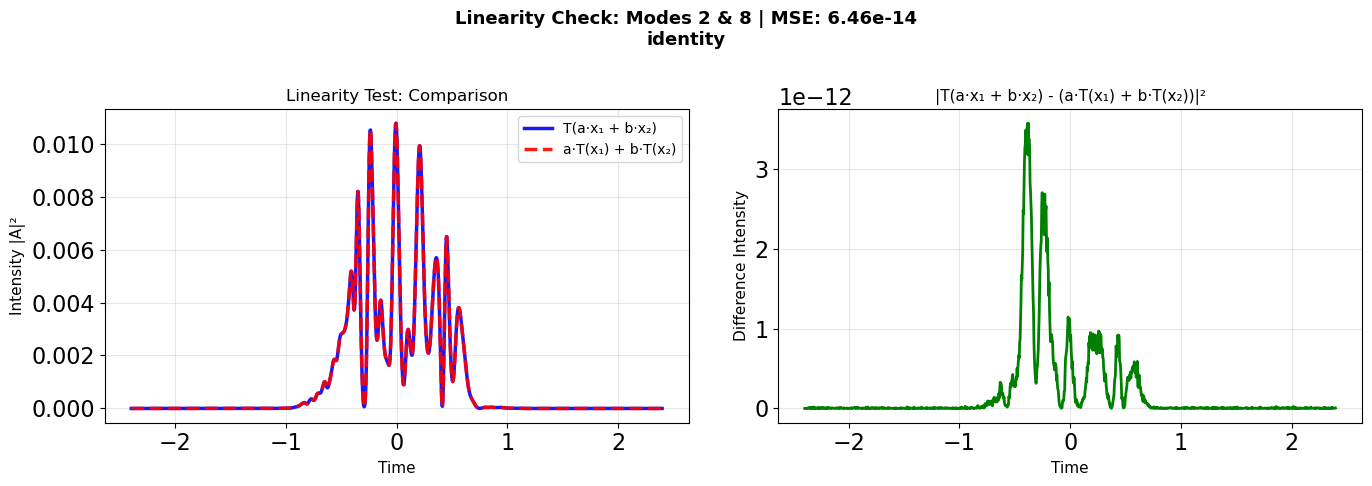

: 

In [ ]:
# Visualization
plot_percent_lin = 0.3
center_points_lin = int(total_points * plot_percent_lin)
start_idx_lin = (total_points - center_points_lin) // 2
end_idx_lin = start_idx_lin + center_points_lin
t_plot_lin = t[start_idx_lin:end_idx_lin].cpu().numpy()

intensity_combined_first = np.abs(output_combined_first.detach().cpu().numpy())[start_idx_lin:end_idx_lin]**2
intensity_combined_after = np.abs(output_combined_after.detach().cpu().numpy())[start_idx_lin:end_idx_lin]**2
intensity_diff = np.abs(difference.detach().cpu().numpy())[start_idx_lin:end_idx_lin]**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Both outputs overlaid
ax1 = axes[0]
ax1.plot(t_plot_lin, intensity_combined_first, 'b-', linewidth=2.5, 
         label='T(a·x₁ + b·x₂)', alpha=0.9)
ax1.plot(t_plot_lin, intensity_combined_after, 'r--', linewidth=2.5, 
         label='a·T(x₁) + b·T(x₂)', alpha=0.9)
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Intensity |A|²', fontsize=11)
ax1.set_title('Linearity Test: Comparison', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right plot: Difference
ax2 = axes[1]
ax2.plot(t_plot_lin, intensity_diff, 'g-', linewidth=2)
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Difference Intensity', fontsize=11)
ax2.set_title('|T(a·x₁ + b·x₂) - (a·T(x₁) + b·T(x₂))|²', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Linearity Check: Modes {mode_1_idx} & {mode_2_idx} | MSE: {mse:.2e}\n{transformation_name}', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
